In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from tqdm import trange
import numpy as np
ROOT = Path.cwd().resolve()
while ROOT.name and not (ROOT / 'hidden_sector_DM').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from hidden_sector_DM.HiddenSectorDM import VectorPortal, BaryonPortal, HiggsPortal       # noqa: E402

from GCE import FIGS_DIR                                       # noqa: E402
from GCE.likelihood import cascade_template, gls_fit, measurement   # noqa: E402
from GCE.pythia_runner import DEFAULT_SEED                     # noqa: E402
from scipy.ndimage import shift as ndimage_shift
from GCE.halo import HALO_2112, RHO_LOCAL_PRIOR
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.path import Path as MplPath
from matplotlib.tri import Triangulation, LinearTriInterpolator
from scipy.ndimage import gaussian_filter, gaussian_filter1d
plt.style.use(ROOT / 'notebooks' / 'mine.mplstyle')
plt.rcParams['axes.axisbelow'] = False

In [2]:
# ---- configuration -------------------------------------------------------
MX_LIM = (15.0, 100.0)   # GeV
MY_LIM = (5.0, 100.0)    # GeV, capped from above by mX
N_POINTS = 16384
N_COLS = 124
DECIMALS = 2

def triangle_grid(n_points: int = N_POINTS, n_cols: int = N_COLS,
                  mx_lim=MX_LIM, my_lim=MY_LIM, decimals: int = DECIMALS):
    """The grid as a (2, `n_points`) array of (mX, mY) in GeV."""
    u = np.linspace(*np.log10(mx_lim), n_cols)          # log10 mX per column
    v_lo = np.log10(my_lim[0])
    v_hi = np.minimum(u, np.log10(my_lim[1]))           # the mY <= mX edge
    height = v_hi - v_lo
    if not (height > 0).all():
        raise ValueError("some column has no room in mY; check the limits")

    # Points per column, proportional to column height.  Largest-remainder
    # apportionment, so the total is exactly `n_points`.
    raw = height / height.sum() * n_points
    n = np.floor(raw).astype(int)
    short = n_points - n.sum()
    if short:
        n[np.argsort(n - raw)[:short]] += 1
    if n.min() < 2:
        raise ValueError(f"column of {n.min()} point(s): lower N_COLS")

    mX = np.repeat(10.0 ** u, n)
    mY = np.concatenate([10.0 ** np.linspace(v_lo, hi, k)
                         for hi, k in zip(v_hi, n)])
    return np.round(np.vstack([mX, mY]), decimals)

STRIDE = 1

def thin(grid, stride: int):
    """Every `stride`-th point in both directions, trapezoid edges kept."""
    if stride == 1:
        return grid
    mX = grid[0]
    starts = np.flatnonzero(np.r_[True, np.diff(mX) != 0.0])   # column starts
    ends = np.r_[starts[1:], mX.size]
    cols = np.unique(np.r_[np.arange(0, starts.size, stride), starts.size - 1])
    keep = np.concatenate([
        np.unique(np.r_[np.arange(starts[c], ends[c], stride), ends[c] - 1])
        for c in cols])
    return grid[:, keep]


GRID = thin(triangle_grid(), STRIDE)    # (2, n) masses in GeV
MX_GRID, MY_GRID = GRID         # flat, one entry per point -- not two axes
print(f"{GRID.shape[1]} of {N_POINTS} points, "
      f"{np.unique(MX_GRID).size} of {N_COLS} mX columns  (STRIDE={STRIDE})")

REGION = "south"        # 'both' (40x40), 'south' or 'north'
N_EVENTS = 200_000      # what the channel_spectra cache holds
SEED = DEFAULT_SEED
ALPHAX = 1e-2           # the dataclass wants a value; it cannot reach the fit

# ---- the fit -------------------------------------------------------------

phi, Cinv = measurement(region=REGION)      # once; independent of the model

n_pts = GRID.shape[1]
chi2 = np.full(n_pts, np.nan)
ts = np.full((n_pts, 14), np.nan)
sigmav = np.full(n_pts, np.nan)
sigmav_err = np.full(n_pts, np.nan)

for k in trange(n_pts):
    mX, mY = (float(v) for v in GRID[:, k])
    model = HiggsPortal(mX=mX, mY=mY, gX=2, gY=3, lam=ALPHAX)
    t = cascade_template(model, n_events=N_EVENTS, seed=SEED)
    ts[k] = t
    sigmav[k], sigmav_err[k], chi2[k] = gls_fit(t, phi, Cinv)

k_best = int(np.nanargmin(chi2))
print(f"\nbest fit: mX={MX_GRID[k_best]:g}, mY={MY_GRID[k_best]:g}, "
      f"chi2={chi2[k_best]:.2f} / {14 - 3} dof")

16384 of 16384 points, 124 of 124 mX columns  (STRIDE=1)


 ... (more hidden) .../home/gab/Desktop/PyCharm_env/hidden_sector_DM/GCE/spectrum.py:80: RuntimeWarning: channel 'Zgam' (BR=2.21e-07) has no PDG mapping; dropped.
  for ch, br in channels_for_species(model.branching_ratios_to_SM(), species):
 ... (more hidden) ...


best fit: mX=72.33, mY=65.86, chi2=15.78 / 11 dof


In [3]:
# ============================================================================
# (mX, <sigma v>) region with the local DM density uncertainty folded into the
# chi2, so the contour inflates smoothly instead of being widened by hand into a
# flat-topped band.  Self-contained: rebuilds the fixed-halo surface on its own
# (wide) <sigma v> axis, then profiles rho_local out of it.
# ============================================================================
sigmav_axis = np.logspace(-27, -24, 700)
sigmav_log_step = np.diff(np.log(sigmav_axis))[0]
mx_columns = np.unique(MX_GRID)
chi2_fixed_halo = np.full((sigmav_axis.size, mx_columns.size), np.nan)
for j in trange(len(mx_columns)):
    mx=mx_columns[j]
    in_column = ((MX_GRID == mx) & np.isfinite(chi2)
                 & np.isfinite(sigmav) & np.isfinite(sigmav_err))
    if not in_column.any():
        continue
    sv_hat, sv_err, chi2_min = (sigmav[in_column], sigmav_err[in_column],
                                chi2[in_column])
    parabola = chi2_min + ((sigmav_axis[:, None] - sv_hat) / sv_err) ** 2
    chi2_fixed_halo[:, j] = parabola.min(axis=1)

# rho_local prior -> chi2 penalty on the log Jbar rescaling.
rho_mean, rho_sigma = RHO_LOCAL_PRIOR # (0.44, 0.13) GeV/cm^3
rho_lognormal_width = rho_sigma / rho_mean
rho_samples = rho_mean * np.exp(np.linspace(-4, 4, 201) * rho_lognormal_width)
ln_jbar_offset = 2.0 * np.log(rho_samples / HALO_2112["rho_local"])          # u
halo_penalty = (np.log(rho_samples / rho_mean) / rho_lognormal_width) ** 2   # P(u)
chi2_marginalised = np.full_like(chi2_fixed_halo, np.inf)
for u, penalty in zip(ln_jbar_offset, halo_penalty):
    shifted = ndimage_shift(chi2_fixed_halo, (-u / sigmav_log_step, 0),
                            order=1, cval=np.inf, mode="constant")
    np.minimum(chi2_marginalised, shifted + penalty, out=chi2_marginalised)

dchi2_fixed_halo = chi2_fixed_halo - np.nanmin(chi2_fixed_halo)
dchi2_marginalised = chi2_marginalised - np.nanmin(chi2_marginalised)

 ... (more hidden) ...


In [4]:
def smoothed_field(mX, mY, dchi2, n_interp=400, sigma=0.5):
    """Delta-chi2 on a regular log grid, lightly smoothed.

    Triangulates in log10 space, interpolates, then smooths with a normalized
    convolution so the domain edge doesn't bleed inward.  Returns (xi, yi, zs)
    with xi, yi in linear GeV; outside the hull is NaN.
    """
    xl, yl = np.log10(mX), np.log10(mY)
    xi, yi = np.meshgrid(np.linspace(xl.min(), xl.max(), n_interp),
                         np.linspace(yl.min(), yl.max(), n_interp))
    zi = LinearTriInterpolator(Triangulation(xl, yl), dchi2)(xi, yi)
    if sigma > 0:
        m = (~np.ma.getmaskarray(zi)).astype(float)      # 1 inside, 0 outside
        z = np.ma.filled(zi, 0.0) * m
        num, den = (gaussian_filter(a, sigma, mode="nearest") for a in (z, m))
        zs = np.where(den > 1e-3, num / np.maximum(den, 1e-12), np.nan)
    else:
        zs = np.ma.filled(zi.astype(float), np.nan)
    return 10.0**xi, 10.0**yi, zs - np.nanmin(zs)   # re-zero: smoothing lifts the min
    
def color_shades(color, n, lightest_alpha=0.25):
    """Generate n shades from `color` to lighter, blended toward white.

    Parameters
    ----------
    color : str or RGB tuple
        Base color (e.g. "tab:blue").
    n : int
        Number of shades.
    lightest_alpha : float
        Fraction of base color in the lightest shade (0=white, 1=original).

    Returns
    -------
    list of hex color strings, from darkest to lightest.
    """
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    fracs = np.linspace(1.0, lightest_alpha, n)
    return [mcolors.to_hex(rgb * f + white * (1 - f)) for f in fracs]

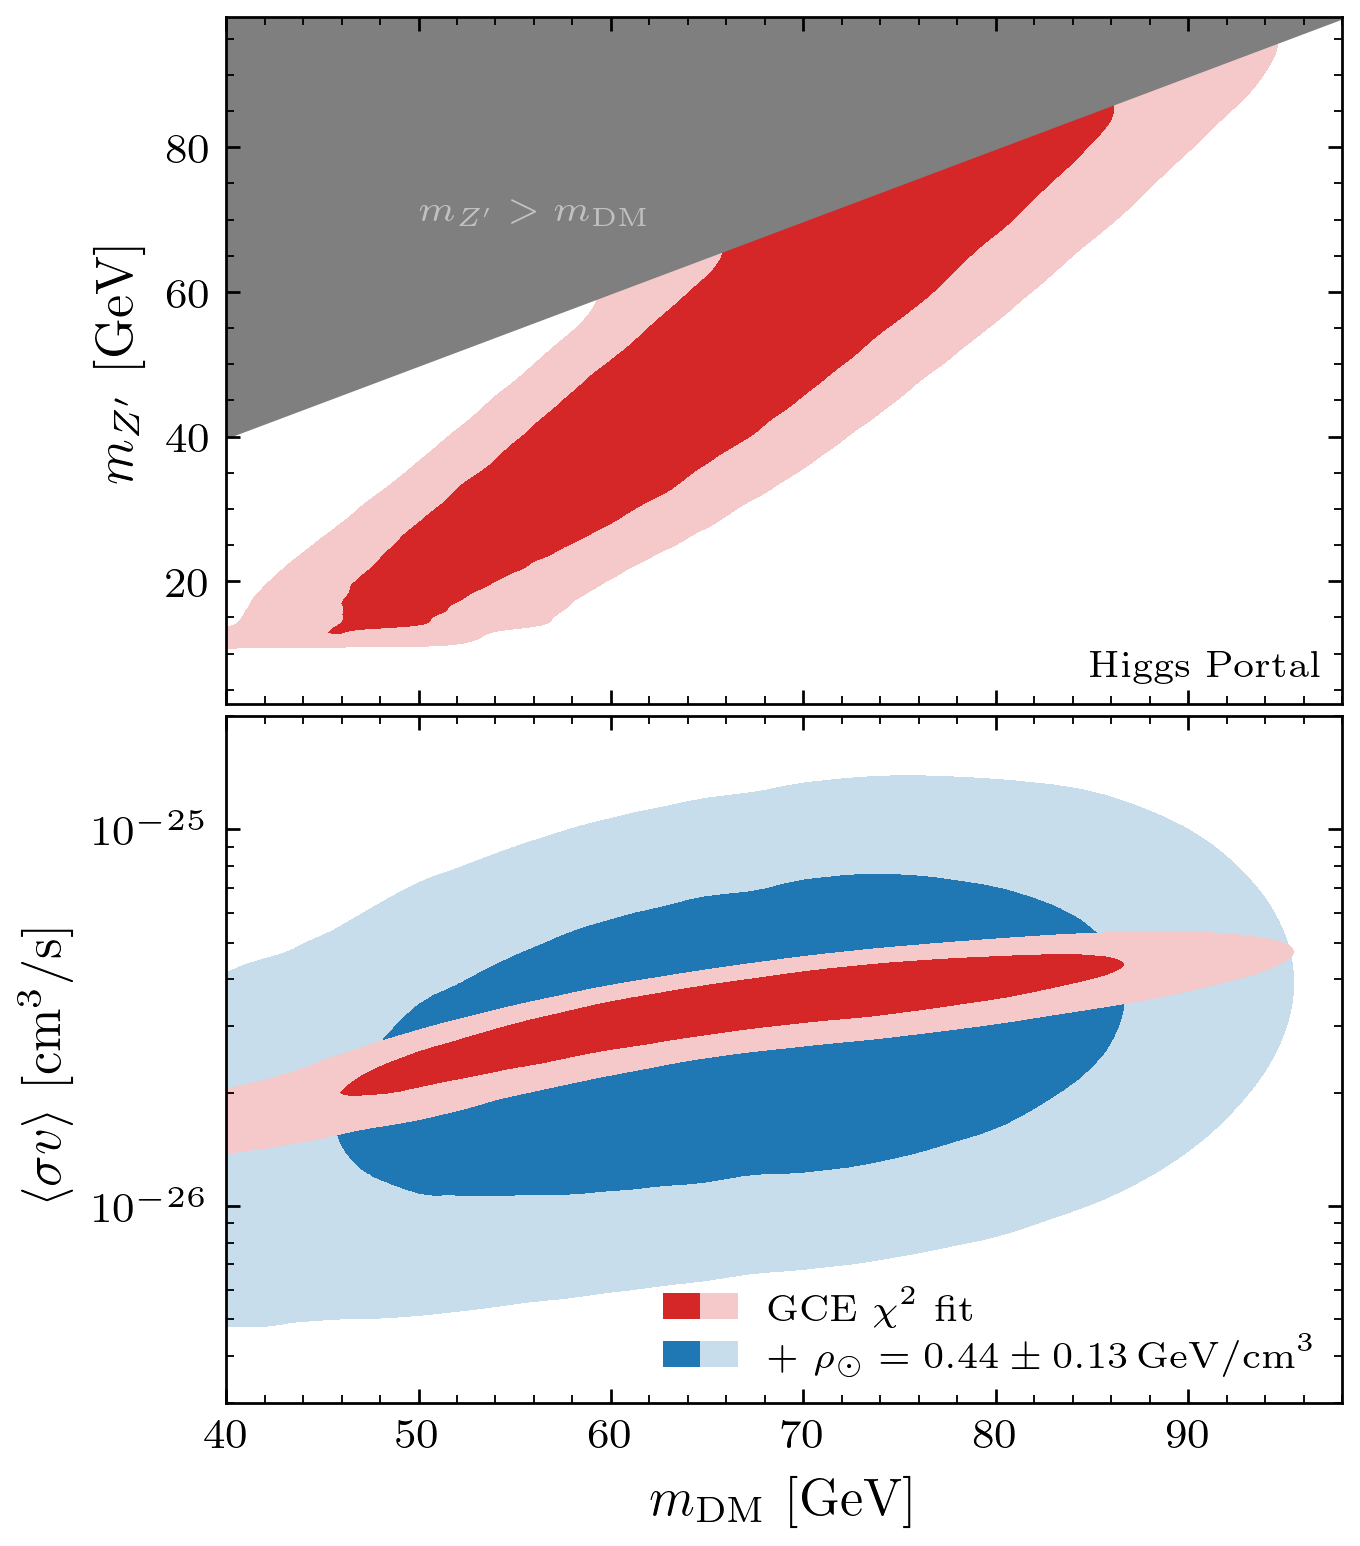

In [5]:
xi, yi, zs = smoothed_field(MX_GRID, MY_GRID, chi2 - chi2[k_best],sigma=3)
dchi2_fixed_halo_smooth   = gaussian_filter1d(dchi2_fixed_halo,   1, axis=1, mode="nearest")
dchi2_marginalised_smooth = gaussian_filter1d(dchi2_marginalised, 1, axis=1, mode="nearest")

label_names=[ 'GCE $\chi^2$ fit', r' + $\rho_{\odot}=0.44\pm 0.13\,{\rm GeV}/{\rm cm}^3$']
fig = plt.figure(figsize=(4, 5))
cs2=color_shades('tab:blue', 2)
cs=color_shades('tab:red', 2)
css=[cs,cs2]
gs = GridSpec(20, 20, figure=fig)  # 7 rows and 7 columns for the triangle plot
ax1= fig.add_subplot(gs[:10, :])
ax2= fig.add_subplot(gs[10:, :])
ax2.set_xlim(40,98)
ax1.set_xlim(40,98)
ax1.set_ylim(3,98)
mDMs=np.linspace(10,100,50)
ax1.fill_between(mDMs,mDMs,np.ones(len(mDMs))*1e4,zorder=2, color='tab:grey')
ax1.contourf(xi, yi,zs, levels=[0.0, 2.30, 6.18], colors=[cs[0], cs[1]], alpha=1)
ax2.contourf(mx_columns, sigmav_axis, dchi2_marginalised_smooth, levels=[0,2.30, 6.18],
           colors=[cs2[0], cs2[1]], alpha=1)
ax2.contourf(mx_columns, sigmav_axis, dchi2_fixed_halo_smooth, levels=[0,2.30, 6.18],
           colors=[cs[0], cs[1]], alpha=1)


ax2.set_xlabel(r"$m_{\rm DM}\,\,[{\rm GeV}]$")
ax1.set_ylabel(r"$m_{Z^\prime}\,\,[{\rm GeV}]$")
ax1.text(50,70,r"$m_{Z^\prime}>m_{\rm DM}$", color="silver",  fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax2.set_ylabel(r"$\langle \sigma v\rangle\,\,[{\rm cm}^3/{\rm s}]$")
ax2.set_yscale("log")
ax2.set_ylim(3e-27,2e-25)
ax1.text(97,7,r'Higgs Portal', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
ax1.set_xticklabels([])

handles,labels=[],[]
for i in range(2):
    patch95 = Patch(facecolor=css[i][1])
    patch68 = Patch(facecolor=css[i][0])
    labels  += [label_names[i]]
    handles += [(patch68, patch95)]
ax2.legend(
    handles=handles,
    labels=labels,
    loc=4,
    fontsize=mpl.rcParams['legend.fontsize'],
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )
plt.savefig("../figs/GCE_spec_example_hP.png")
#plt.savefig("../figs/GCE_spec_example_hP.pdf")
plt.show()
plt.close()

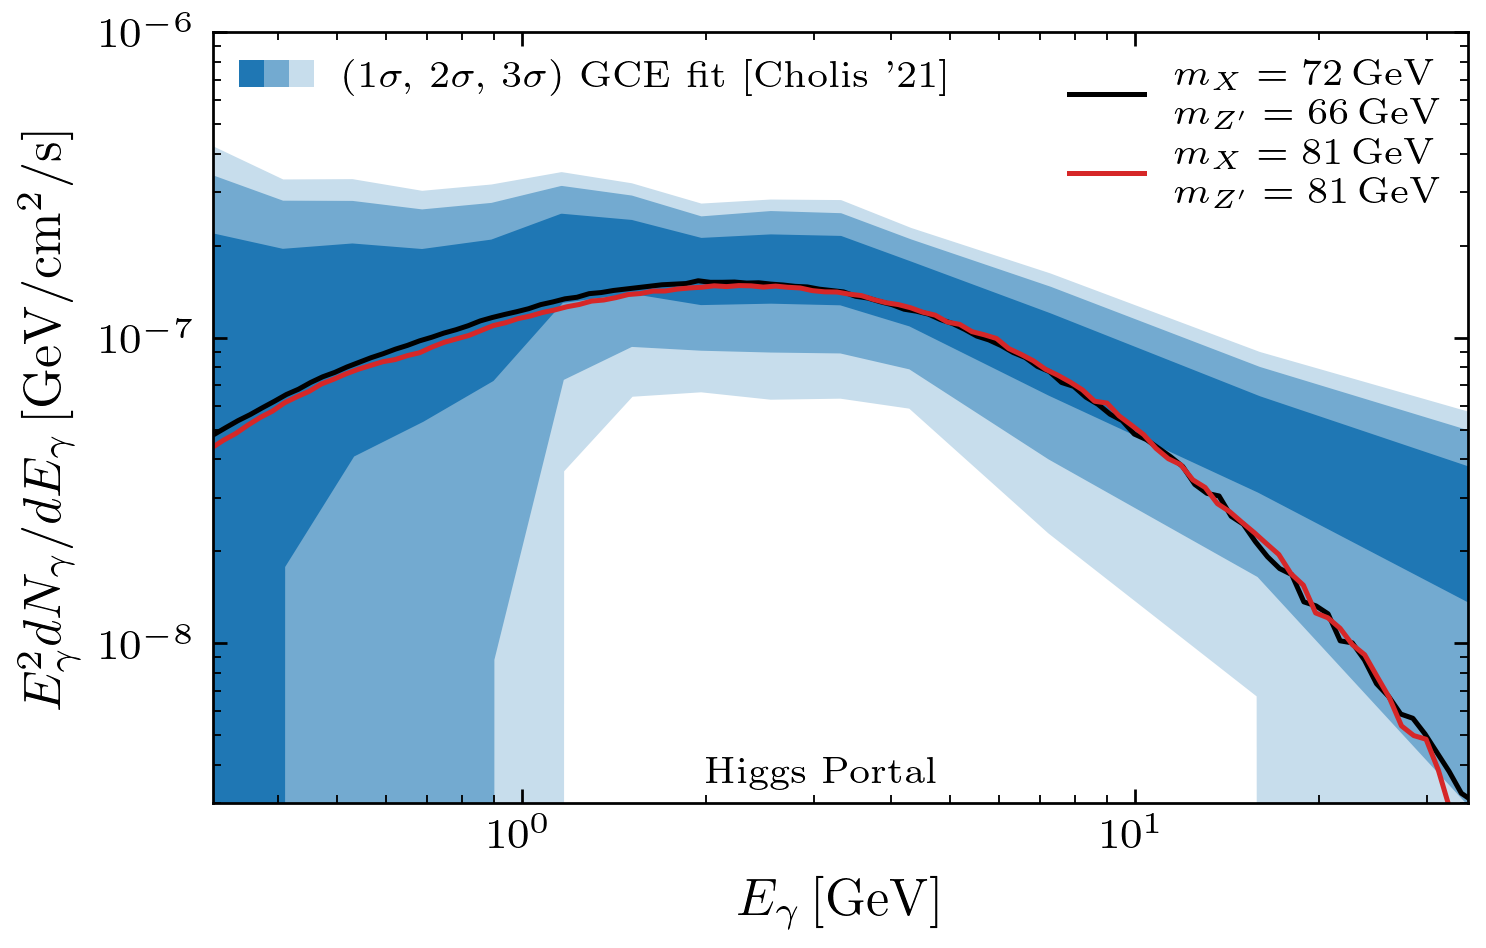

In [7]:
from GCE.gce_data import EBIN_CTR
from GCE.spectrum import cascade_flux, default_ebins, direct_flux
from GCE.halo import j_factor, HALO_2112
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.path import Path as MplPath

_, dOmega = j_factor(return_solid_angle=True, **{**HALO_2112, "roi": REGION})
k_bad=-2612
cs=color_shades('tab:blue', 3)
C = np.linalg.inv(Cinv)
draws = np.random.default_rng(0).multivariate_normal(phi, C, size=20000)
lo68, hi68 = np.percentile(draws, [16, 84], axis=0)
lo95, hi95 = np.percentile(draws, [2.5, 97.5], axis=0)
lo99, hi99 = np.percentile(draws, [0.5, 99.5], axis=0)
model_best = HiggsPortal(mX=float(MX_GRID[k_best]), mY=float(MY_GRID[k_best]), gX=2, gY=3,
                             lam=ALPHAX)
flux_best=cascade_flux(model_best,default_ebins(model_best.mX, n_bins=180), sigmav=sigmav[k_best], n_events=N_EVENTS, seed=SEED)
model_bad = HiggsPortal(mX=float(MX_GRID[k_bad]), mY=float(MY_GRID[k_bad]), gX=2, gY=3,
                             lam=ALPHAX)
flux_bad=cascade_flux(model_bad,default_ebins(model_bad.mX, n_bins=180), sigmav=sigmav[k_bad], n_events=N_EVENTS, seed=SEED)



plt.fill_between(EBIN_CTR, lo99*dOmega, hi99*dOmega, color=cs[2],alpha=1)
plt.fill_between(EBIN_CTR, lo95*dOmega, hi95*dOmega, color=cs[1],alpha=1)
plt.fill_between(EBIN_CTR, lo68*dOmega, hi68*dOmega, color=cs[0],alpha=1)
#plt.plot(EBIN_CTR,ts[k_best]*sigmav[k_best],c='k',lw=1)
#plt.plot(EBIN_CTR,ts[k_bad]*sigmav[k_bad],c='tab:blue',lw=1)
plt.plot(flux_best[0], flux_best[0]**2*flux_best[1]*dOmega, c='k', lw=1,
         label=rf'$m_X={MX_GRID[k_best]:.0f}\,\mathrm{{GeV}}$' + '\n'
               + rf'$m_{{Z^\prime}}={MY_GRID[k_best]:.0f}\,\mathrm{{GeV}}$')
plt.plot(flux_bad[0], flux_bad[0]**2*flux_bad[1]*dOmega, c='tab:red', lw=1,
         label=rf'$m_X={MX_GRID[k_bad]:.0f}\,\mathrm{{GeV}}$' + '\n'
               + rf'$m_{{Z^\prime}}={MY_GRID[k_bad]:.0f}\,\mathrm{{GeV}}$')
leg1 = plt.legend()
p99 = Patch(facecolor=cs[2])
p95 = Patch(facecolor=cs[1])
p68 = Patch(facecolor=cs[0])
leg2=plt.legend(
    handles=[(p68, p95, p99)],
    labels=["$(1\sigma,\,2\sigma,\,3\sigma)$ GCE fit [Cholis '21]"],
    loc=2,
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )
plt.gca().add_artist(leg1)
plt.yscale("log")
plt.xscale("log")
plt.ylim(3e-9,1e-6)
plt.xlim(EBIN_CTR[0],EBIN_CTR[-1])
plt.ylabel(r"$E^2_\gamma dN_\gamma/dE_\gamma\,[{\rm GeV}/{\rm cm}^2/{\rm s}]$")
plt.xlabel(r"$E_\gamma\,[{\rm GeV}]$")
plt.text(2,3.5e-9,r'Higgs Portal', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
plt.savefig("../figs/GCE_spec_example_hP.png")
#plt.savefig("../figs/GCE_spec_example_hP.pdf")
plt.show()
plt.close()